**DIAMOND A-DC PBSHM Coding Challenge**

---

- **Name**: Ernest Toochukwu, Samuel
- **Date**: 02-04-2026

---
### Task1: Population Exploration (EDA)
**Objectives:**

- Visualize the distribution of structure sizes and geometry
- Explore the starter population graph
- Inspect the provided measurement-like node features
- Propose which raw or derived features might be damage-sensitive


In [ ]:
"""
Importing necessary libraries and setting up the environment
for data analysis and visualization.
"""

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
from sklearn.cluster import KMeans



plt.style.use('seaborn-v0_8')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def load_and_prepare_data(
    structures_json_path: str,
    labels_csv_path: str,
    edges_csv_path: str,
    weights_csv_path: str
):
    """
    Loads raw dataset files and prepares node-level and structure-level DataFrames.

    Responsibilities:
    - Load raw JSON + CSV files
    - Flatten node-level data
    - Merge labels into node-level dataset
    - Build structure-level feature table

    Returns:
        structures (list): Raw structure data
        nodes_dataframe (pd.DataFrame): Node-level features with labels
        structure_dataframe (pd.DataFrame): Structure-level features
        edges_dataframe (pd.DataFrame): Population graph edges
        weights_dataframe (pd.DataFrame): Population graph weights
    """

    import json
    import pandas as pd

    # ============================================================
    # LOAD RAW DATA
    # ============================================================
    with open(structures_json_path) as json_file:
        structure_collection = json.load(json_file)

    labels_dataframe = pd.read_csv(labels_csv_path)

    edges_dataframe = pd.read_csv(edges_csv_path)
    weights_dataframe = pd.read_csv(weights_csv_path)

    # ============================================================
    # NODE-LEVEL FLATTENING
    # ============================================================
    flattened_node_records = []

    for structure_entry in structure_collection:

        structure_identifier = structure_entry["structure_id"]
        number_of_storeys = structure_entry["n_storeys"]

        for node_entry in structure_entry["node_features"]:

            node_record = node_entry.copy()

            node_record["structure_id"] = structure_identifier
            node_record["n_storeys"] = number_of_storeys

            flattened_node_records.append(node_record)

    nodes_dataframe = pd.DataFrame(flattened_node_records)

    # Attach labels to each node
    nodes_dataframe = nodes_dataframe.merge(
        labels_dataframe,
        on="structure_id"
    )

    # ============================================================
    # STRUCTURE-LEVEL FEATURES
    # ============================================================
    structure_records = []

    for structure_entry in structure_collection:

        structure_identifier = structure_entry["structure_id"]

        total_structure_height = sum(
            node["height_m"] for node in structure_entry["node_features"]
        )

        structure_label = labels_dataframe.loc[
            labels_dataframe.structure_id == structure_identifier,
            "damaged"
        ].values[0]

        structure_records.append({
            "structure_id": structure_identifier,
            "n_storeys": structure_entry["n_storeys"],
            "total_height": total_structure_height,
            "damaged": structure_label
        })

    structure_dataframe = pd.DataFrame(structure_records)

    return (
        structure_collection,
        nodes_dataframe,
        structure_dataframe,
        edges_dataframe,
        weights_dataframe,
        labels_dataframe
    )


# ============================================================
# VISUALIZATION: STRUCTURE DISTRIBUTION
# ============================================================

def plot_structure_distribution(structure_dataframe):
    """
    Plots total vs damaged structure distribution by number of storeys.

    Args:
        structure_dataframe (pd.DataFrame):
            Must contain ['structure_id', 'n_storeys', 'damaged']
    """

    import seaborn as sns
    import matplotlib.pyplot as plt

    # ============================================================
    # PREPARE DATA
    # ============================================================
    unique_structure_dataframe = structure_dataframe[
        ["structure_id", "n_storeys", "damaged"]
    ].drop_duplicates()

    total_structure_storey_counts = unique_structure_dataframe["n_storeys"]

    damaged_structure_storey_counts = unique_structure_dataframe[
        unique_structure_dataframe["damaged"] == 1
    ]["n_storeys"]

    # ============================================================
    # PLOT
    # ============================================================
    plt.figure(figsize=(10, 6))

    sns.countplot(
        x=total_structure_storey_counts,
        color="blue",
        label="Total Structures"
    )

    sns.countplot(
        x=damaged_structure_storey_counts,
        color="red",
        label="Damaged Structures"
    )

    plt.title("Structure Distribution: Total vs Damaged by Storey Count")
    plt.xlabel("Number of Storeys")
    plt.ylabel("Structure Count")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# GRAPH VISUALIZATION UTILS
# ============================================================

def plot_structure_graph(structure_collection, structure_index: int = 0):
    """
    Visualizes a single structure graph.

    Args:
        structure_collection (list): Raw structures
        structure_index (int): Index of structure to visualize
    """

    import networkx as nx
    import matplotlib.pyplot as plt

    selected_structure = structure_collection[structure_index]

    structure_graph = nx.Graph()
    structure_graph.add_edges_from(selected_structure["edges"])

    plt.figure(figsize=(4, 4))

    nx.draw(
        structure_graph,
        with_labels=True,
        node_size=200,
        font_size=8
    )

    plt.title(f"Structure {selected_structure['structure_id']} Graph")
    # plt.tight_layout()
    plt.show()


def plot_population_graph(edges_dataframe):
    """
    Visualizes the population-level graph.

    Args:
        edges_dataframe (pd.DataFrame): Must contain ['source', 'target']
    """

    import networkx as nx
    import matplotlib.pyplot as plt

    population_graph = nx.from_pandas_edgelist(
        edges_dataframe,
        source="source",
        target="target"
    )

    plt.figure(figsize=(4, 4))

    nx.draw(
        population_graph,
        node_size=50,
        with_labels=False
    )

    plt.title("Population Graph (Geometry-based)")
    # plt.tight_layout()
    plt.show()


def plot_boxplot(dataframe, x_col, y_col, hue_col, title, y_label):
    """
    Generates a boxplot showing the distribution of a variable (y_col) across storeys (x_col)
    with an optional hue for damage status.

    Args:
        dataframe (pd.DataFrame): The input DataFrame containing the data.
        x_col (str): The name of the column for the x-axis (e.g., 'storey').
        y_col (str): The name of the column for the y-axis (e.g., 'height_m').
        hue_col (str): The name of the column to use for hue (e.g., 'damaged').
        title (str): The title of the plot.
        y_label (str): The label for the y-axis.
    """
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=dataframe,
        x=x_col,
        y=y_col,
        hue=hue_col,
    )
    plt.title(title)
    plt.xlabel(x_col.replace('_', ' ').title())
    plt.ylabel(y_label)
    plt.show()

def generate_node_features(nodes_dataframe):
    """
    Generates new engineered features for the node-level DataFrame.

    Args:
        nodes_dataframe (pd.DataFrame): The input node-level DataFrame.

    Returns:
        pd.DataFrame: The DataFrame with new engineered features.
    """
    # New Feature 1: Frequency Squared (Measured Stiffness Proxy)
    nodes_dataframe['dominant_modal_frequency_Hz_squared'] = nodes_dataframe['dominant_modal_frequency_Hz']**2

    # New Feature 2: Inverse Height Cubed (Theoretical Stiffness Proxy)
    nodes_dataframe['inverse_height_cubed'] = 1 / (nodes_dataframe['height_m']**3)

    # New Feature 3: Frequency times Height (Material Property Proxy / Shear Wave Velocity proxy)
    nodes_dataframe['frequency_times_height'] = nodes_dataframe['dominant_modal_frequency_Hz'] * nodes_dataframe['height_m']

    # New Feature: Absolute difference in dominant_modal_frequency_Hz_squared between adjacent storeys
    # Using .diff() requires sorting by structure_id and storey to ensure correct 'adjacent' calculation
    # Create a temporary sorted DataFrame for the diff calculation
    temp_sorted_df = nodes_dataframe.sort_values(by=['structure_id', 'storey'])
    nodes_dataframe['abs_dominant_modal_frequency_Hz_squared_diff'] = temp_sorted_df.groupby('structure_id')['dominant_modal_frequency_Hz_squared'].diff().abs()

    # New Feature: Local deviation of dominant_modal_frequency_Hz_squared from structure's mean
    nodes_dataframe['local_dominant_modal_frequency_Hz_squared_dev'] = nodes_dataframe.groupby('structure_id')['dominant_modal_frequency_Hz_squared'].transform(lambda x: (x - x.mean()).abs())

    # New Feature: Local deviation of frequency_times_height from structure's mean
    nodes_dataframe['local_frequency_times_height_dev'] = nodes_dataframe.groupby('structure_id')['frequency_times_height'].transform(lambda x: (x - x.mean()).abs())

    return nodes_dataframe

def generate_structure_features(structure_dataframe, nodes_dataframe):
    """
    Generates new engineered features for the structure-level DataFrame.

    Args:
        structure_dataframe (pd.DataFrame): The input structure-level DataFrame.
        nodes_dataframe (pd.DataFrame): The input node-level DataFrame (with engineered features).

    Returns:
        pd.DataFrame: The structure-level DataFrame with new engineered features.
    """
    # Calculate std for dominant_modal_frequency_Hz from nodes_dataframe
    freq_std = nodes_dataframe.groupby('structure_id')['dominant_modal_frequency_Hz'].std()
    # Calculate std for dominant_modal_frequency_Hz_squared from nodes_dataframe
    freq_sq_std = nodes_dataframe.groupby('structure_id')['dominant_modal_frequency_Hz_squared'].std()
    # Calculate std for inverse_height_cubed from nodes_dataframe
    inv_h_cubed_std = nodes_dataframe.groupby('structure_id')['inverse_height_cubed'].std()

    # Map the calculated std values back to the structure_dataframe based on 'structure_id'
    # Ensure the structure_id in structure_dataframe is used for mapping against the series index
    structure_dataframe['frequency_std_times_total_height'] = structure_dataframe['structure_id'].map(freq_std) * structure_dataframe['total_height']
    structure_dataframe['frequency_Hz_squared_std'] = structure_dataframe['structure_id'].map(freq_sq_std)
    structure_dataframe['inverse_height_cubed_std'] = structure_dataframe['structure_id'].map(inv_h_cubed_std)

    # Calculate inverse_total_height_cubed directly from structure_dataframe
    structure_dataframe['inverse_total_height_cubed'] = 1 / (structure_dataframe['total_height']**3)

    return structure_dataframe


In [ ]:
#-//--------- Data Loading and Preprocessing ---------//-

structures_json_path = '/content/drive/MyDrive/PBSHM-challenge/structures_measurements.json'
labels = '/content/drive/MyDrive/PBSHM-challenge/structure_labels.csv'
edges_path = '/content/drive/MyDrive/PBSHM-challenge/population_edges_geometry.csv'
weights_path = '/content/drive/MyDrive/PBSHM-challenge/population_edge_weights_geometry.csv'


structure_collection,nodes_df, structure_df, edges, weights, labels = load_and_prepare_data(structures_json_path,
                                                                                                                      labels,
                                                                                                                      edges_path,
                                                                                                                      weights_path)

In [ ]:
# nodes_df.head()

In [ ]:
# structure_df.head()

#### VISUALIZATION: STRUCTURE DISTRIBUTION BY SIZE

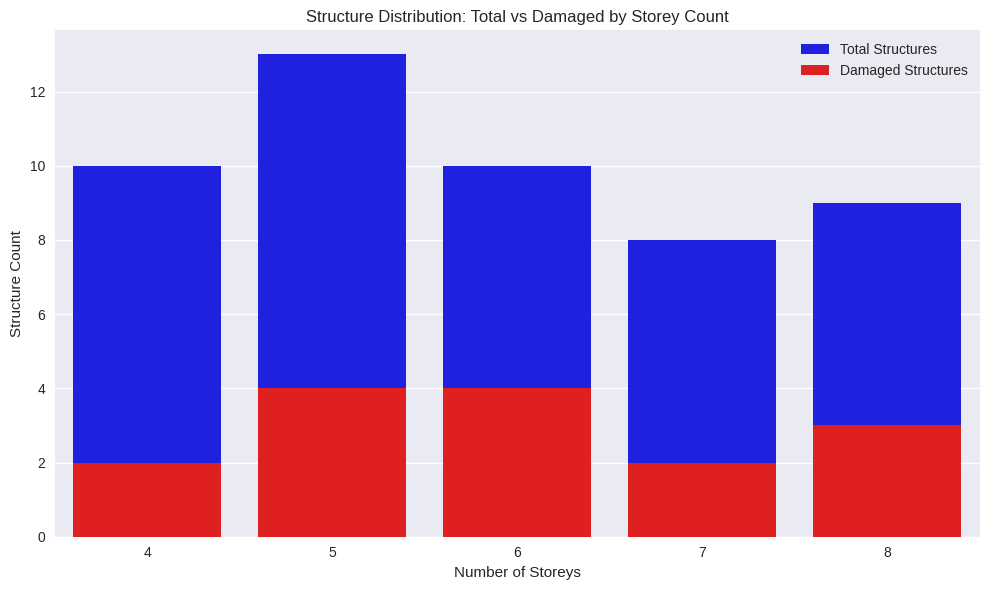

In [ ]:
plot_structure_distribution(structure_df)

- **Structure Size Distribution**: The plot shows a right-skewed distribution for the number of storeys, with a higher prevalence of shorter buildings (e.g., 4-5 storeys) than taller buildings (e.g., 7-8 storeys).
- **Damage Distribution**: The proportion of damaged structures (red bars) relative to the total structures (blue bars) appears to be consistent across different storey counts. This suggests that damage is not preferentially concentrated in structures of a particular size.

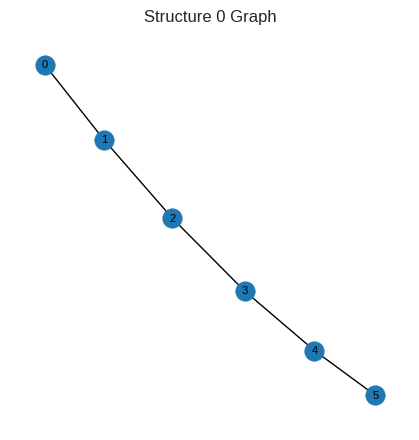

In [ ]:
structure_index = 0
plot_structure_graph(structure_collection, structure_index)

### Structure Graph Observations:
---
*   The graph for `structure_id=0` (and similar individual structure graphs) clearly shows a linear chain of nodes (storeys) connected by edges. This visual representation matches the expected 'shear frame' model where each storey is connected to its adjacent storeys.

*   The nodes are labeled with their storey numbers, providing a clear mapping of the structure's vertical configuration.


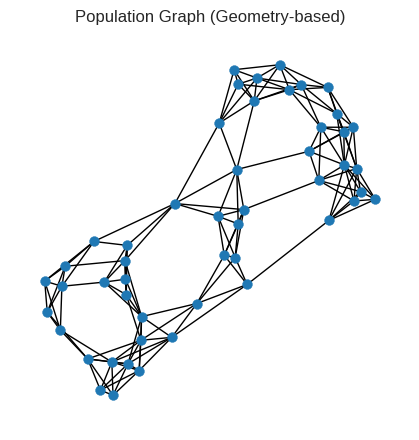

In [ ]:
plot_population_graph(edges)

**Population Graph:**
---

*   The population graph, composed of 50 nodes (representing 50 structures), displays a highly interconnected network. This suggests that many structures share similar geometric properties, leading to numerous connections based on the 'geometry-based' edges.

*   The dense clustering in the graph indicates a high degree of similarity among structures within the population, which can be useful for population-based damage detection methods.

## Inspection of Node features Measurement



In [ ]:
nodes_df.head()

,storey,height_m,dominant_modal_frequency_Hz,structure_id,n_storeys,damaged,damage_storey
0,0,3.532,2.66633,0,6,0,NaN
1,1,4.938,8.06059,0,6,0,NaN
2,2,4.558,4.46783,0,6,0,NaN
3,3,4.434,2.66633,0,6,0,NaN
4,4,3.899,5.19604,0,6,0,NaN


In [1]:
nodes_df.describe()

NameError: name 'nodes_df' is not defined

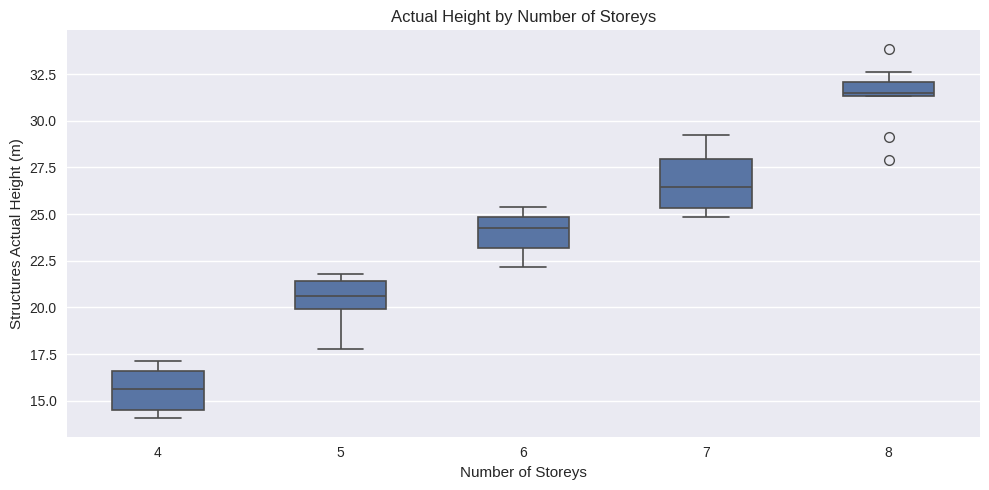

In [ ]:
# Boxplot of Structure total height by number of storeys
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=structure_df,
    x='n_storeys',
    y='total_height',
    color='#4C72B0',   # clean, professional blue
    width=0.5,
    linewidth=1.2
)

plt.title("Actual Height by Number of Storeys")
plt.xlabel("Number of Storeys")
plt.ylabel("Structures Actual Height (m)")
plt.tight_layout()
plt.show()



Observation: Structure height is directly correlated with the number of stories, although there may be slight local variations at the node level.

### Inspect raw height data signal

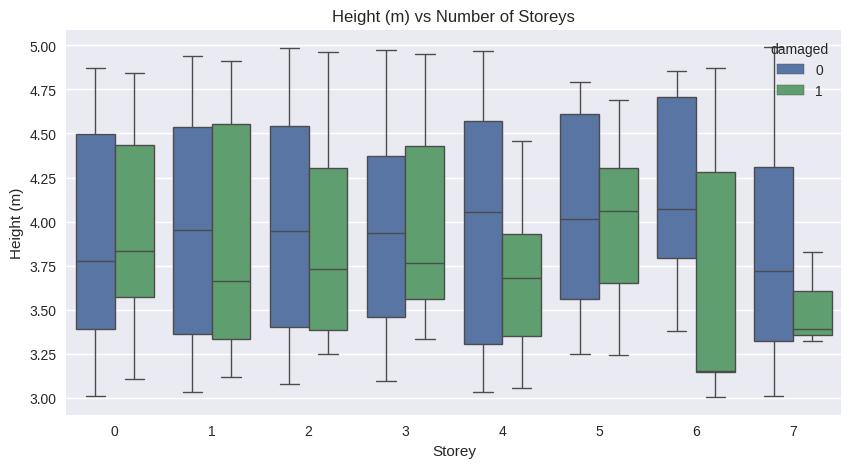

In [ ]:


# Call the function for 'height_m' data
plot_boxplot(
    dataframe=nodes_df,
    x_col='storey',
    y_col='height_m',
    hue_col='damaged',
    title='Height (m) vs Number of Storeys',
    y_label='Height (m)'
)

### Inspect raw frequency data Signal

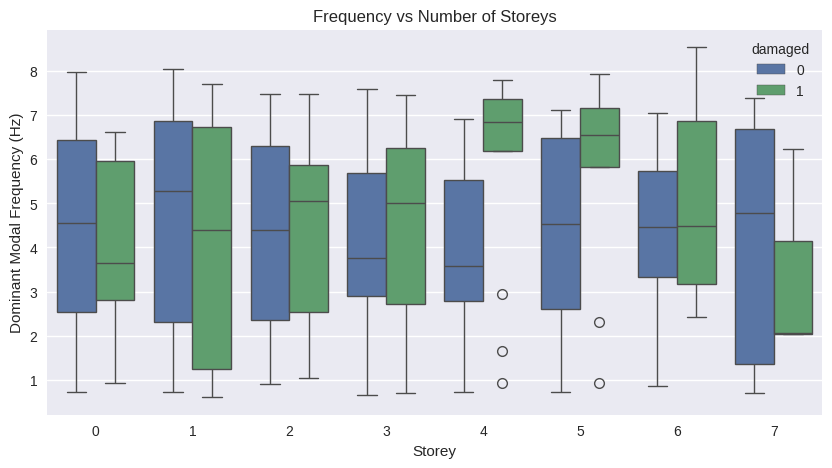

In [ ]:

# Plot Frequency vs Number of Storeys
plot_boxplot(
    dataframe=nodes_df,
    x_col='storey',
    y_col='dominant_modal_frequency_Hz',
    hue_col='damaged',
    title="Frequency vs Number of Storeys",
    y_label="Dominant Modal Frequency (Hz)"
)



### Check Correlations of Raw Data

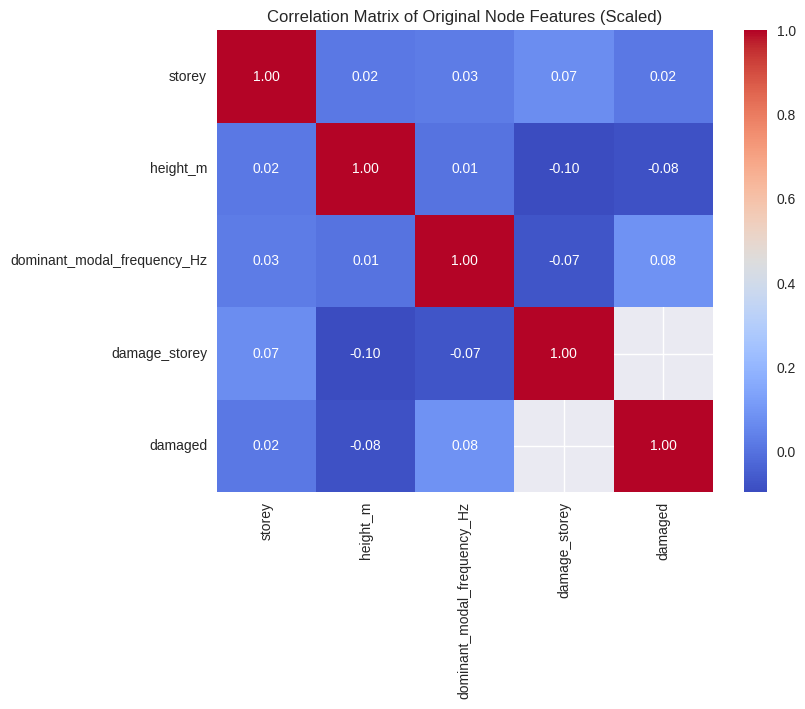

In [ ]:
# Original node features
node_feature_cols = [
    'storey',
    'height_m',
    'dominant_modal_frequency_Hz',
    'damage_storey',
    'damaged'
]

correlation_matrix_nodes = nodes_df[node_feature_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_nodes, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Original Node Features (Scaled)")
plt.show()

## Observation:
- There is a significant overlap between damaged and undamaged structures.

**Key takeaway:**
- Raw frequency or height alone is not sufficient, but it remains informative.
---

# Node Feature Engineering Motivation

The fundamental relationship governing structural dynamics is:

$ [
\omega \propto \sqrt{\frac{K}{M}}
] $

where $ ( \omega ) $ is the natural frequency, $ ( K ) $ is stiffness, and $ ( M ) $is mass.  
Structural damage reduces stiffness locally, producing deviations in frequency across adjacent storeys.



| Feature | Formula | Physics Meaning | Why it helps |
|---|---|---|---|
| Measured Stiffness Proxy | $\omega^2$ | Dynamic Response | Tells the model how the building actually behaves based on its vibration data. |
| Theoretical Stiffness Proxy | $1/h^3$ | Geometric Constraint | Tells the model what the stiffness should be for a structure of that specific height. |
| Material Property Proxy | $\omega \cdot h$ | Shear Wave Velocity ($V_s$) | Relates to the speed of wave propagation, identifying the building material (e.g., steel vs. concrete) regardless of height. |

References

* Chopra, A. K. (2017). Dynamics of Structures: Theory and Applications to Earthquake Engineering. Pearson. (Fundamental relationship of $k = \omega^2 m$ and shear frame stiffness $k = 12EI/h^3$).
* Kramer, S. L. (1996). Geotechnical Earthquake Engineering. Prentice Hall. (Relation between frequency, height, and shear wave velocity $V_s \approx 4h \cdot f$).

Do you need the Python code to generate these features from your raw $h$ and $\omega$ columns?



In [ ]:

# Apply the feature engineering function to nodes_df to generate drived features
nodes_df = generate_node_features(nodes_df)

nodes_df.tail()

,storey,height_m,dominant_modal_frequency_Hz,structure_id,n_storeys,damaged,damage_storey,dominant_modal_frequency_Hz_squared,inverse_height_cubed,frequency_times_height,abs_dominant_modal_frequency_Hz_squared_diff,local_dominant_modal_frequency_Hz_squared_dev,local_frequency_times_height_dev
288,7,3.010,0.72382,48,8,0,NaN,0.523915,0.036669,2.178698,3.422545,14.676833,9.117549
289,0,3.386,6.61031,49,4,1,3.0,43.696198,0.025760,22.382510,NaN,16.406201,3.741503
290,1,4.083,6.61031,49,4,1,3.0,43.696198,0.014691,26.989896,0.000000,16.406201,8.348889
291,2,3.258,3.29906,49,4,1,3.0,10.883797,0.028917,10.748337,32.812401,16.406201,7.892669
292,3,4.378,3.29906,49,4,1,3.0,10.883797,0.011917,14.443285,0.000000,16.406201,4.197722


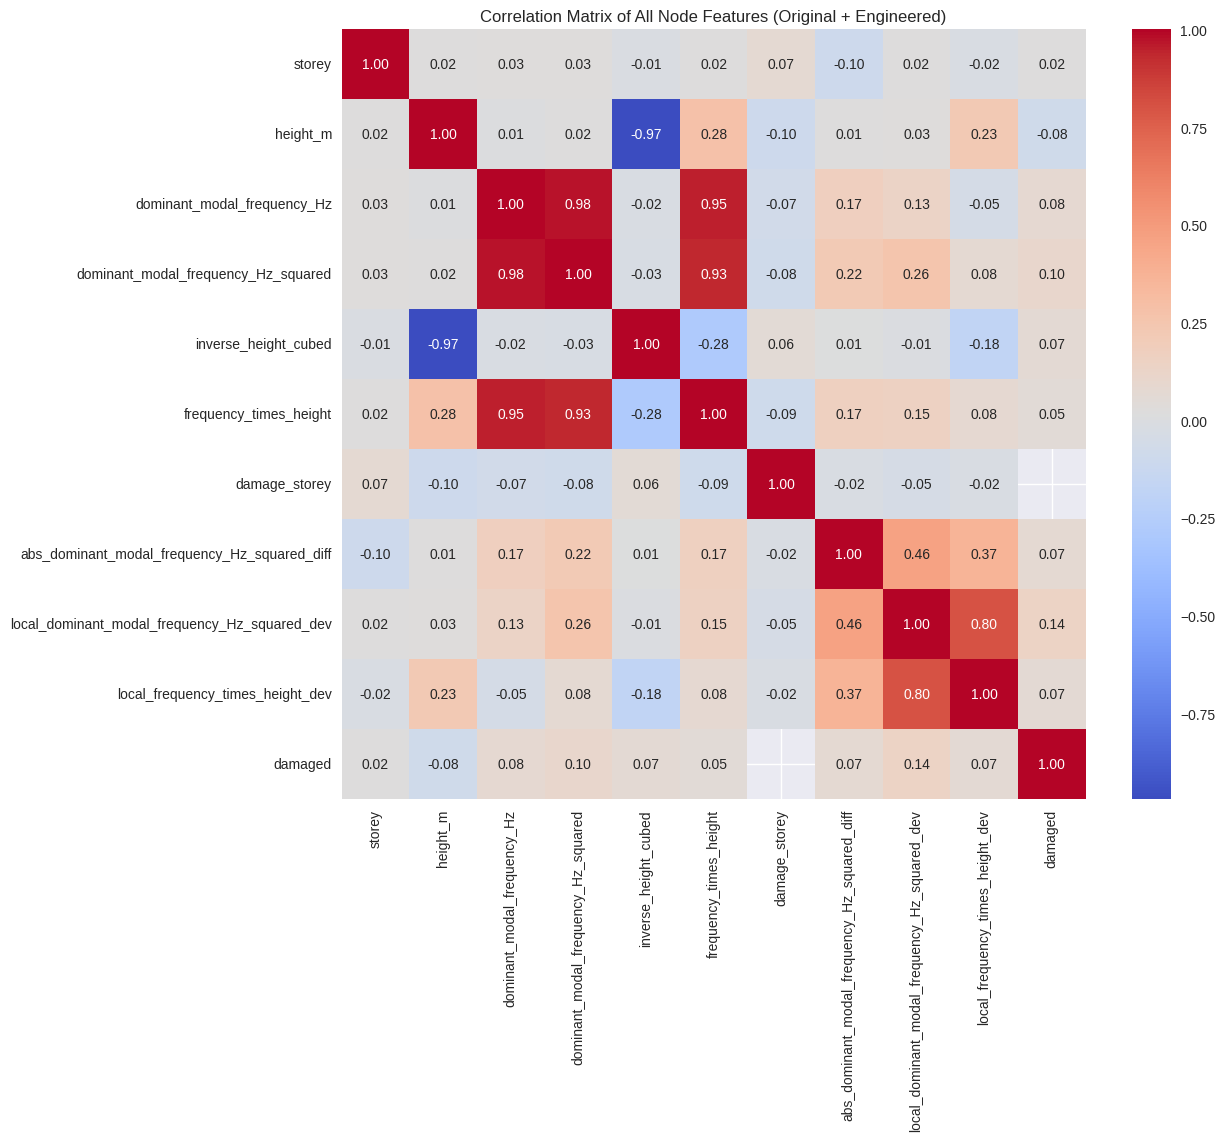

In [ ]:
feature_columns = [
    'storey',
    'height_m',
    'dominant_modal_frequency_Hz',
    'dominant_modal_frequency_Hz_squared',
    'inverse_height_cubed',
    'frequency_times_height',
    'damage_storey',
    'abs_dominant_modal_frequency_Hz_squared_diff',
    'local_dominant_modal_frequency_Hz_squared_dev',
    'local_frequency_times_height_dev',
    'damaged'
]


correlation_matrix_nodes_engineered = nodes_df[feature_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_nodes_engineered, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of All Node Features (Original + Engineered)")
plt.show()

## Selected Node Data

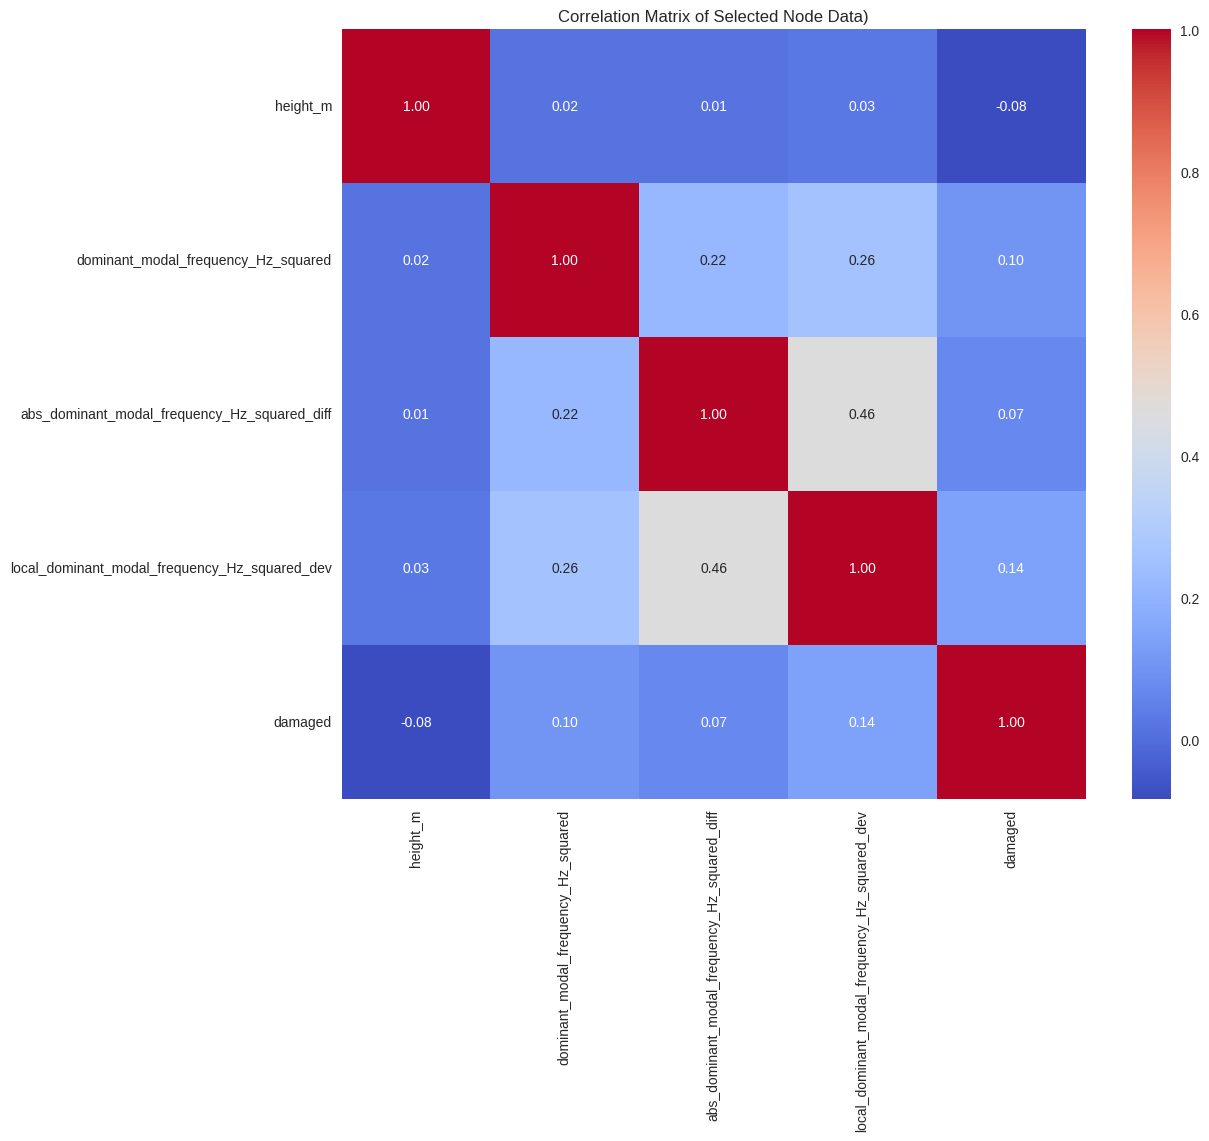

In [ ]:
selected_node_columns = [
    'height_m',
    'dominant_modal_frequency_Hz_squared',
    'abs_dominant_modal_frequency_Hz_squared_diff',
    'local_dominant_modal_frequency_Hz_squared_dev',
    'damaged'
]


correlation_matrix_nodes_engineered = nodes_df[selected_node_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_nodes_engineered, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Selected Node Data)")
plt.show()

# Node level Data Insignt:
- Improvements in feature information was observed for Frequency signal (r=0.10)
- local height signal did not improve with the feature engineering(r=0.07)

---
The following node-level features are identified from the correlation analysis, ranked by their statistical significance relative to the damaged state:

| Feature | Correlation ($r$) | Physical Justification |
|---|---|---|
| $\text{Local Frequency }^2 Deviation$ | $0.14$ | Measures localized stiffness variance relative to adjacent nodes; strongest indicator of nodal-level anomalies. |
| $\text{Dominant Modal Frequency}^2$ | $0.10$ | Direct proxy for nodal stiffness ($k \propto \omega^2$); fundamental indicator of structural integrity at the point of measurement. |
| $\text{Absolute Frequency }^2 Difference$ | $0.07$ | Captures the magnitude of frequency shifts between sequential nodes; highlights discontinuities in the load path. |
| $ \text{Node Height ($h$) }$| $-0.08$ | Minimal correlation; indicates that damage occurrence is independent of vertical nodal position within the shear-frame. |
---

**Nodel level Summary of Findings**

At the node level:
- $\text{Local Frequency }^2 Deviation$ is the most significant variable for damage detection.
- The dynamic features consistently outperform geometric features ($h$), confirming that localized shifts in frequency response provide a more robust signal for structural health monitoring than absolute spatial coordinates.



## Structure Level Feature Data Engineering


In [ ]:
# Call function to generate structure-level features
structure_df = generate_structure_features(structure_df, nodes_df)

In [ ]:
structure_df.head()

,structure_id,n_storeys,total_height,damaged,frequency_std_times_total_height,frequency_Hz_squared_std,inverse_total_height_cubed,inverse_height_cubed_std
0,0,6,24.905,0,62.890163,23.539426,0.000065,0.006237
1,1,5,19.219,0,38.811851,22.900213,0.000141,0.009751
2,2,8,32.077,0,37.989516,12.433084,0.000030,0.008727
3,3,6,22.181,1,56.705535,25.117397,0.000092,0.002201
4,4,7,29.248,1,68.461296,25.170422,0.000040,0.006831


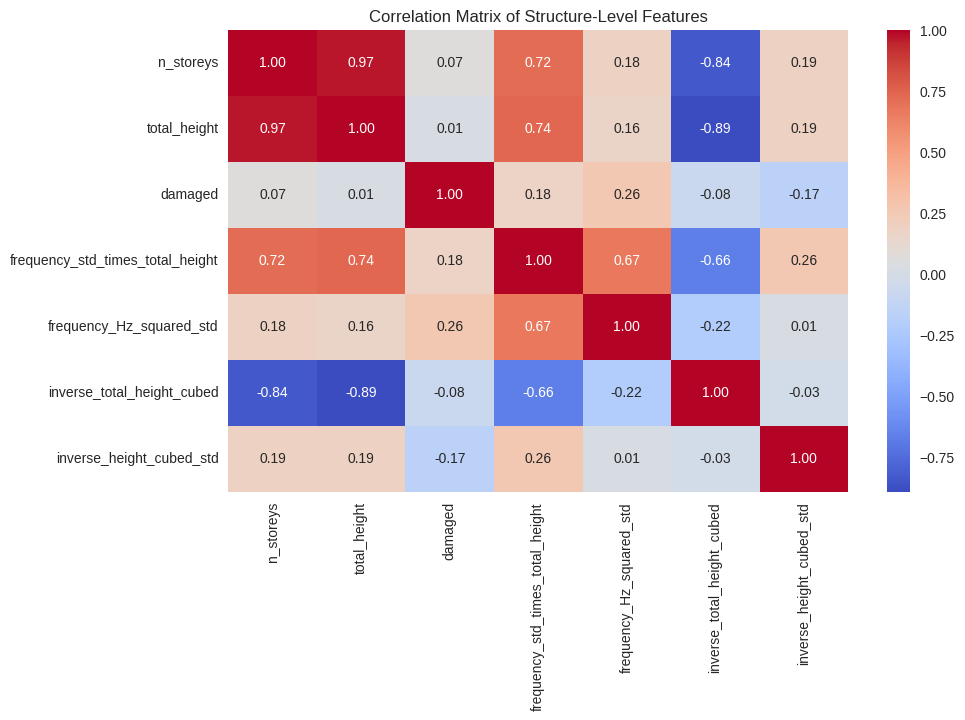

In [ ]:
# Compute the correlation matrix without 'structure_id' as it is an identifier
correlation_matrix = structure_df.drop(columns=['structure_id']).corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Structure-Level Features")
plt.show()

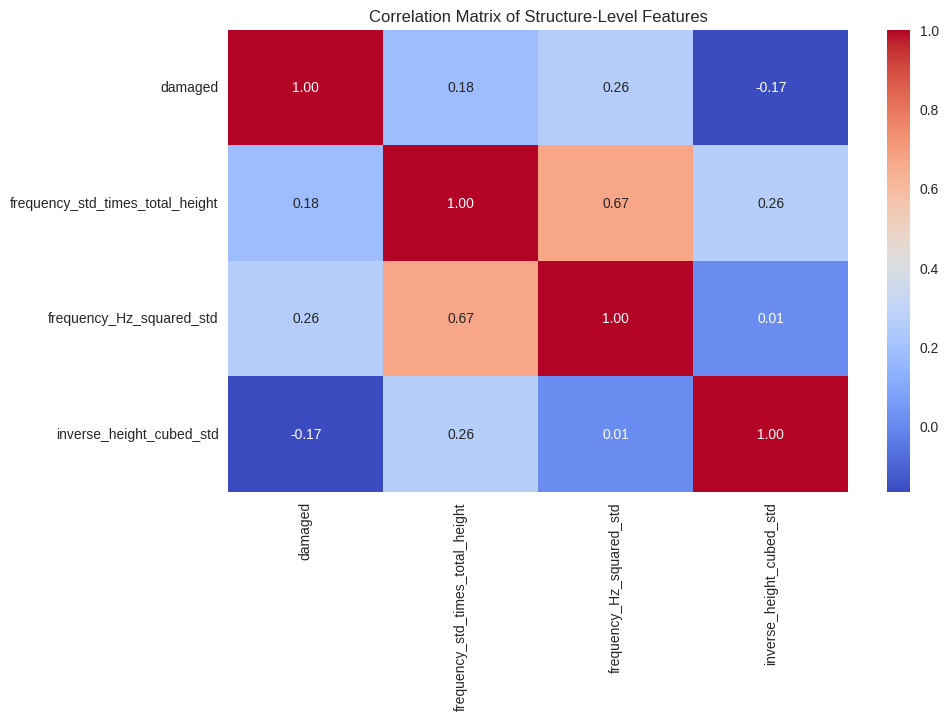

In [ ]:
# Compute the correlation matrix without 'structure_id' as it is an identifier
selected_structure_correlation_matrix = structure_df.drop(columns=['structure_id', 'n_storeys', 'total_height', 'inverse_total_height_cubed', ]).corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(selected_structure_correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Structure-Level Features")
plt.show()

# Structur level feauture engineering summary

------------------------------

The following three features have been selected to represent the physical and dynamic characteristics of the building at a global scale:

| Feature | Physical Approximation | Model Input Name |
|---|---|---|
| Measured Stiffness Variance | $\omega^2$ (Standard Deviation) | frequency_Hz_squared_std |
| Material Property Variance | $\omega \cdot H$ ($\omega$ Standard Deviation) | frequency_std_times_total_height |
| Geometric Stiffness Variance | $1/h^3$ (Standard Deviation) | inverse_height_cubed_std |

------------------------------
Key Observations and Insights

* **Frequency as a Damage Indicator**: The frequency-based signals, specifically the squared frequency (frequency_Hz_squared_std), show the highest correlation with the damaged state ($0.26$). This confirms that **frequency is the most damage-sensitive** signal, as any loss in structural integrity (stiffness) directly manifests as a shift in the natural frequency.


* **Significance of Structural Level over Node Level**: A key observation is that both local height variance and frequency variance are significantly more informative at the structure level than at the individual node level. These sugests that aggregating these signals allows the model to capture global structural behavior (like inter-story drift or total shear-frame response) that is lost when looking at nodes in isolation.

* **Signal Strength in Sparse Correlations**: While the raw correlation coefficients may appear relatively low (ranging from $0.17$ to $0.26$), they remain significant indicators for this structural analysis. In the context of engineering data, predictive power may be poor due to limitation in data quantity and quality.

------------------------------

